# Weed Portfolio

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

import warnings
warnings.filterwarnings("ignore")

# yahoo finance data 
import yfinance as yf
yf.pdr_override()

In [2]:
# input
title = "Weed"
symbols = ['ABBV', 'BUD', 'MO','TAP','SMG','CGC', 'GWPH', 'CRON', 'ACB', 'TLRY', 'CRBP', 'CTST', 'NBEV', 'TRTC', 'CANN', 'MJ']
start = '2018-01-01'
end = '2020-06-25'

In [3]:
df = pd.DataFrame()
for s in symbols:
    df[s] = yf.download(s,start,end)['Adj Close']

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

In [4]:
from datetime import datetime
from dateutil import relativedelta

d1 = datetime.strptime(start, "%Y-%m-%d")
d2 = datetime.strptime(end, "%Y-%m-%d")
delta = relativedelta.relativedelta(d2,d1)
print('How many years of investing?')
print('%s years' % delta.years)

How many years of investing?
2 years


In [5]:
number_of_years = delta.years

In [6]:
days = (df.index[-1] - df.index[0]).days
days

904

In [7]:
df.head()

,ABBV,BUD,MO,TAP,SMG,CGC,GWPH,CRON,ACB,TLRY,CRBP,CTST,NBEV,TRTC,CANN,MJ
Date,,,,,,,,,,,,,,,,
2018-01-02,85.888794,104.851608,59.916634,76.489159,102.167892,25.879999,134.089996,NaN,113.760002,NaN,7.95,NaN,2.220,6.90,8.15,32.423748
2018-01-03,87.232849,105.663048,59.696426,75.754410,102.346863,28.650000,134.410004,NaN,135.720001,NaN,8.50,NaN,2.177,6.15,10.35,34.465618
2018-01-04,86.735374,105.952171,59.459267,76.265945,100.001511,25.889999,133.919998,NaN,125.400002,NaN,8.35,NaN,2.120,4.20,7.76,32.332596
2018-01-05,88.245255,107.015411,59.628662,77.130905,101.395546,27.389999,133.429993,NaN,127.320000,NaN,7.80,NaN,2.170,5.10,8.06,33.225918
2018-01-08,86.831360,106.278618,59.552422,77.958679,102.770699,32.110001,131.500000,NaN,134.220001,NaN,8.10,NaN,2.140,5.55,9.87,35.021660


In [8]:
df.tail()

,ABBV,BUD,MO,TAP,SMG,CGC,GWPH,CRON,ACB,TLRY,CRBP,CTST,NBEV,TRTC,CANN,MJ
Date,,,,,,,,,,,,,,,,
2020-06-18,96.230003,51.779999,41.470001,39.080002,129.850006,17.180000,131.179993,6.56,13.01,8.56,7.97,NaN,1.74,0.13,0.4725,13.66
2020-06-19,96.709999,50.439999,40.689999,38.029999,129.429993,17.330000,129.710007,6.42,13.37,8.30,7.68,NaN,1.70,0.12,0.4600,13.51
2020-06-22,97.269997,50.880001,40.049999,37.950001,130.149994,17.370001,125.849998,6.45,13.72,8.41,7.84,NaN,1.64,0.11,0.4101,13.50
2020-06-23,97.309998,52.099998,40.340000,37.970001,131.929993,17.240000,125.000000,6.53,13.58,8.56,8.15,NaN,1.62,0.11,0.4280,13.56
2020-06-24,95.139999,48.919998,39.430000,36.500000,129.580002,16.709999,121.680000,6.38,13.67,8.15,7.96,NaN,1.50,0.11,0.4111,13.17


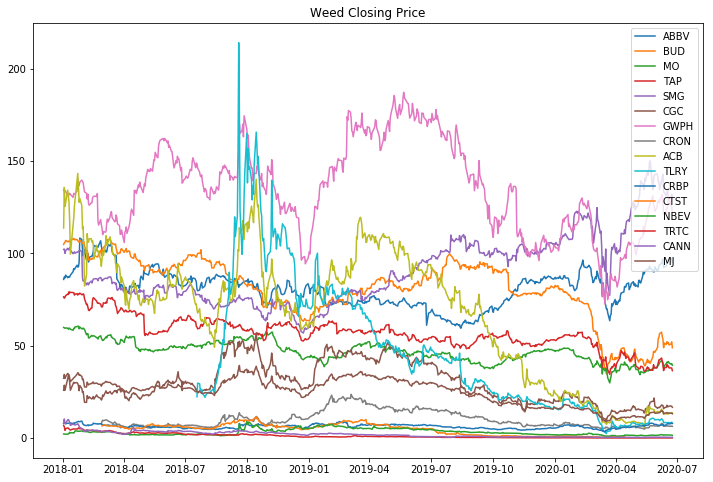

In [9]:
plt.figure(figsize=(12,8))
plt.plot(df)
plt.title(title + ' Closing Price')
plt.legend(labels=df.columns)

In [10]:
# Normalize the data
normalize = (df - df.min())/ (df.max() - df.min())

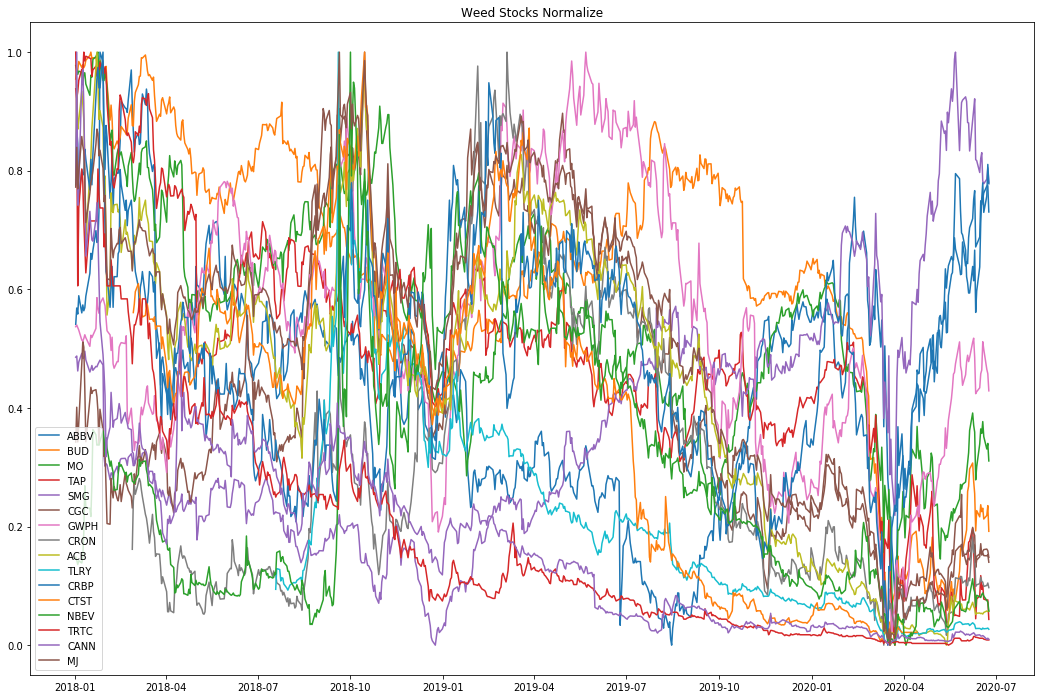

In [11]:
plt.figure(figsize=(18,12))
plt.plot(normalize)
plt.title(title + ' Stocks Normalize')
plt.legend(labels=normalize.columns)

In [12]:
stock_rets = df.pct_change().dropna()

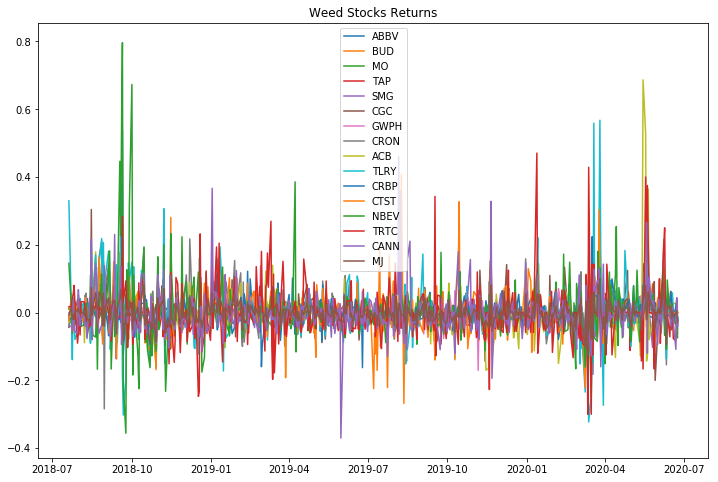

In [13]:
plt.figure(figsize=(12,8))
plt.plot(stock_rets)
plt.title(title + ' Stocks Returns')
plt.legend(labels=stock_rets.columns)

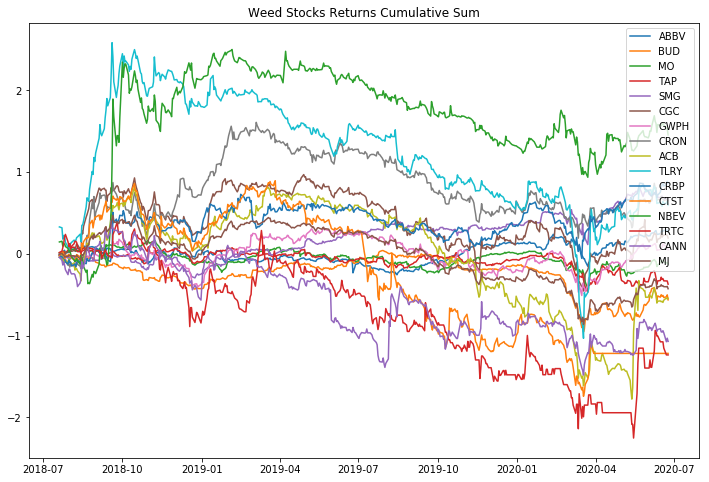

In [14]:
plt.figure(figsize=(12,8))
plt.plot(stock_rets.cumsum())
plt.title(title + ' Stocks Returns Cumulative Sum')
plt.legend(labels=stock_rets.columns)

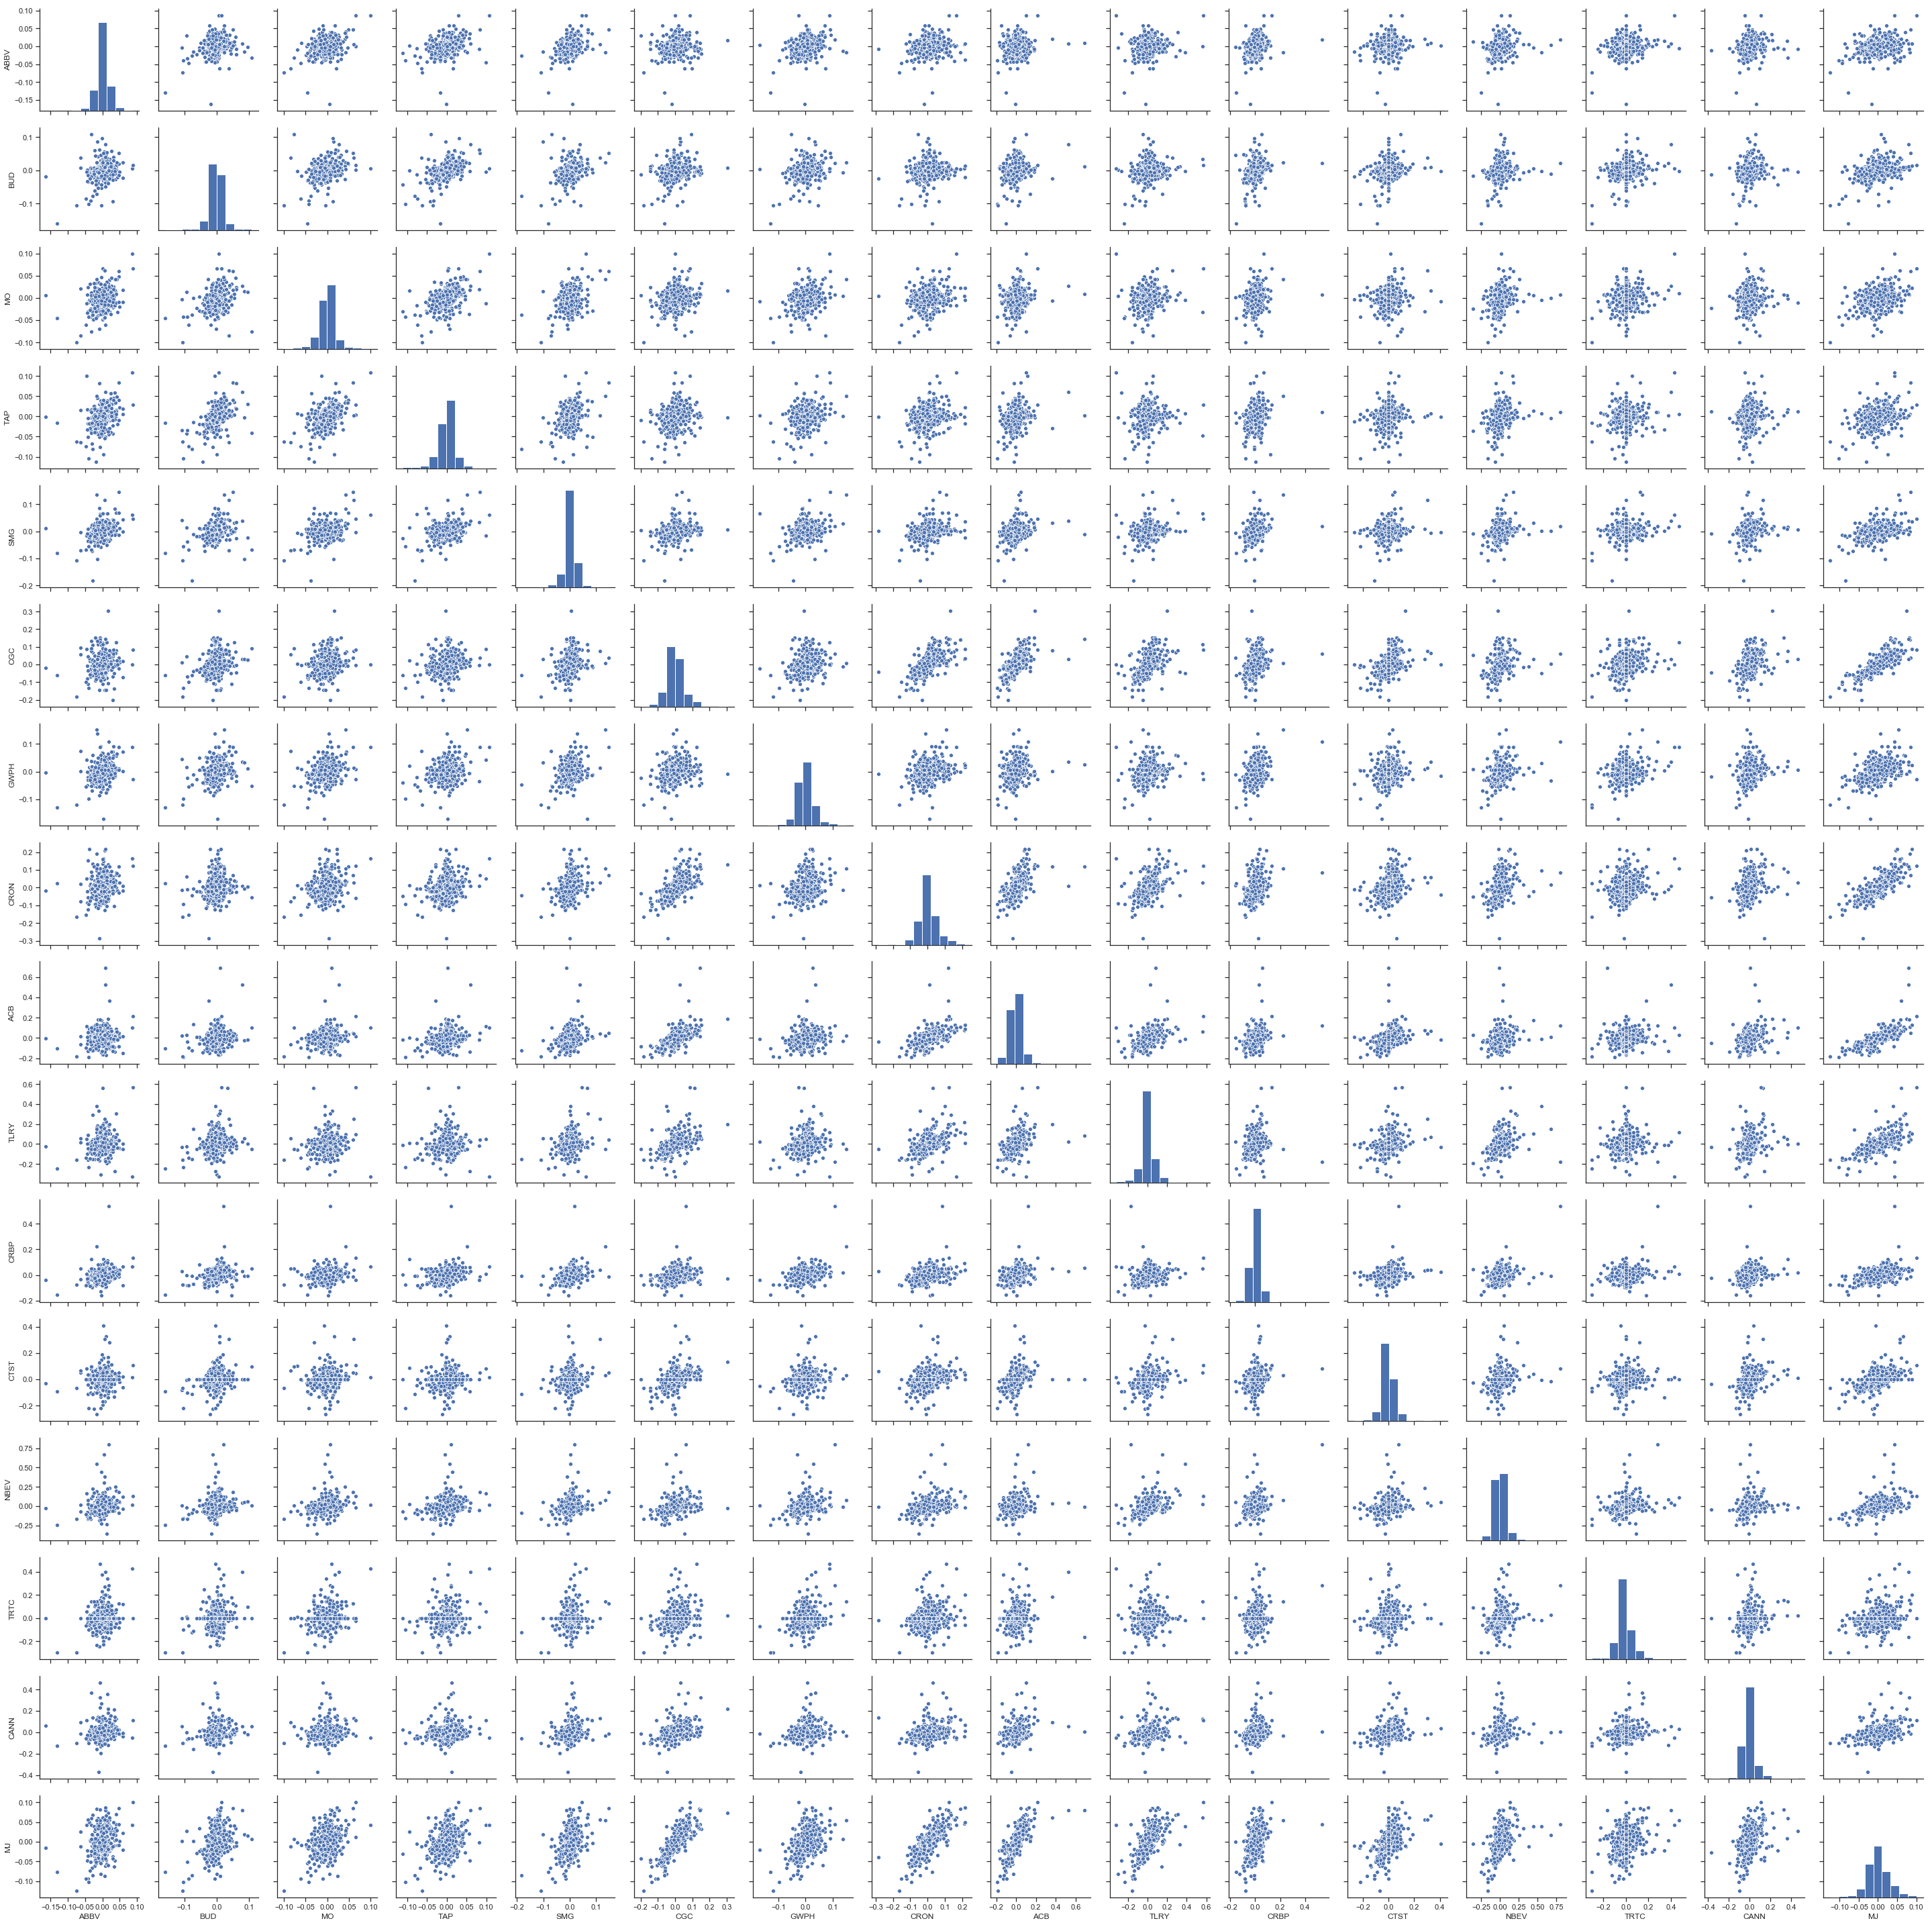

In [15]:
sns.set(style='ticks')
ax = sns.pairplot(stock_rets, diag_kind='hist')

nplot = len(stock_rets.columns)
for i in range(nplot) :
    for j in range(nplot) :
        ax.axes[i, j].locator_params(axis='x', nbins=6, tight=True)

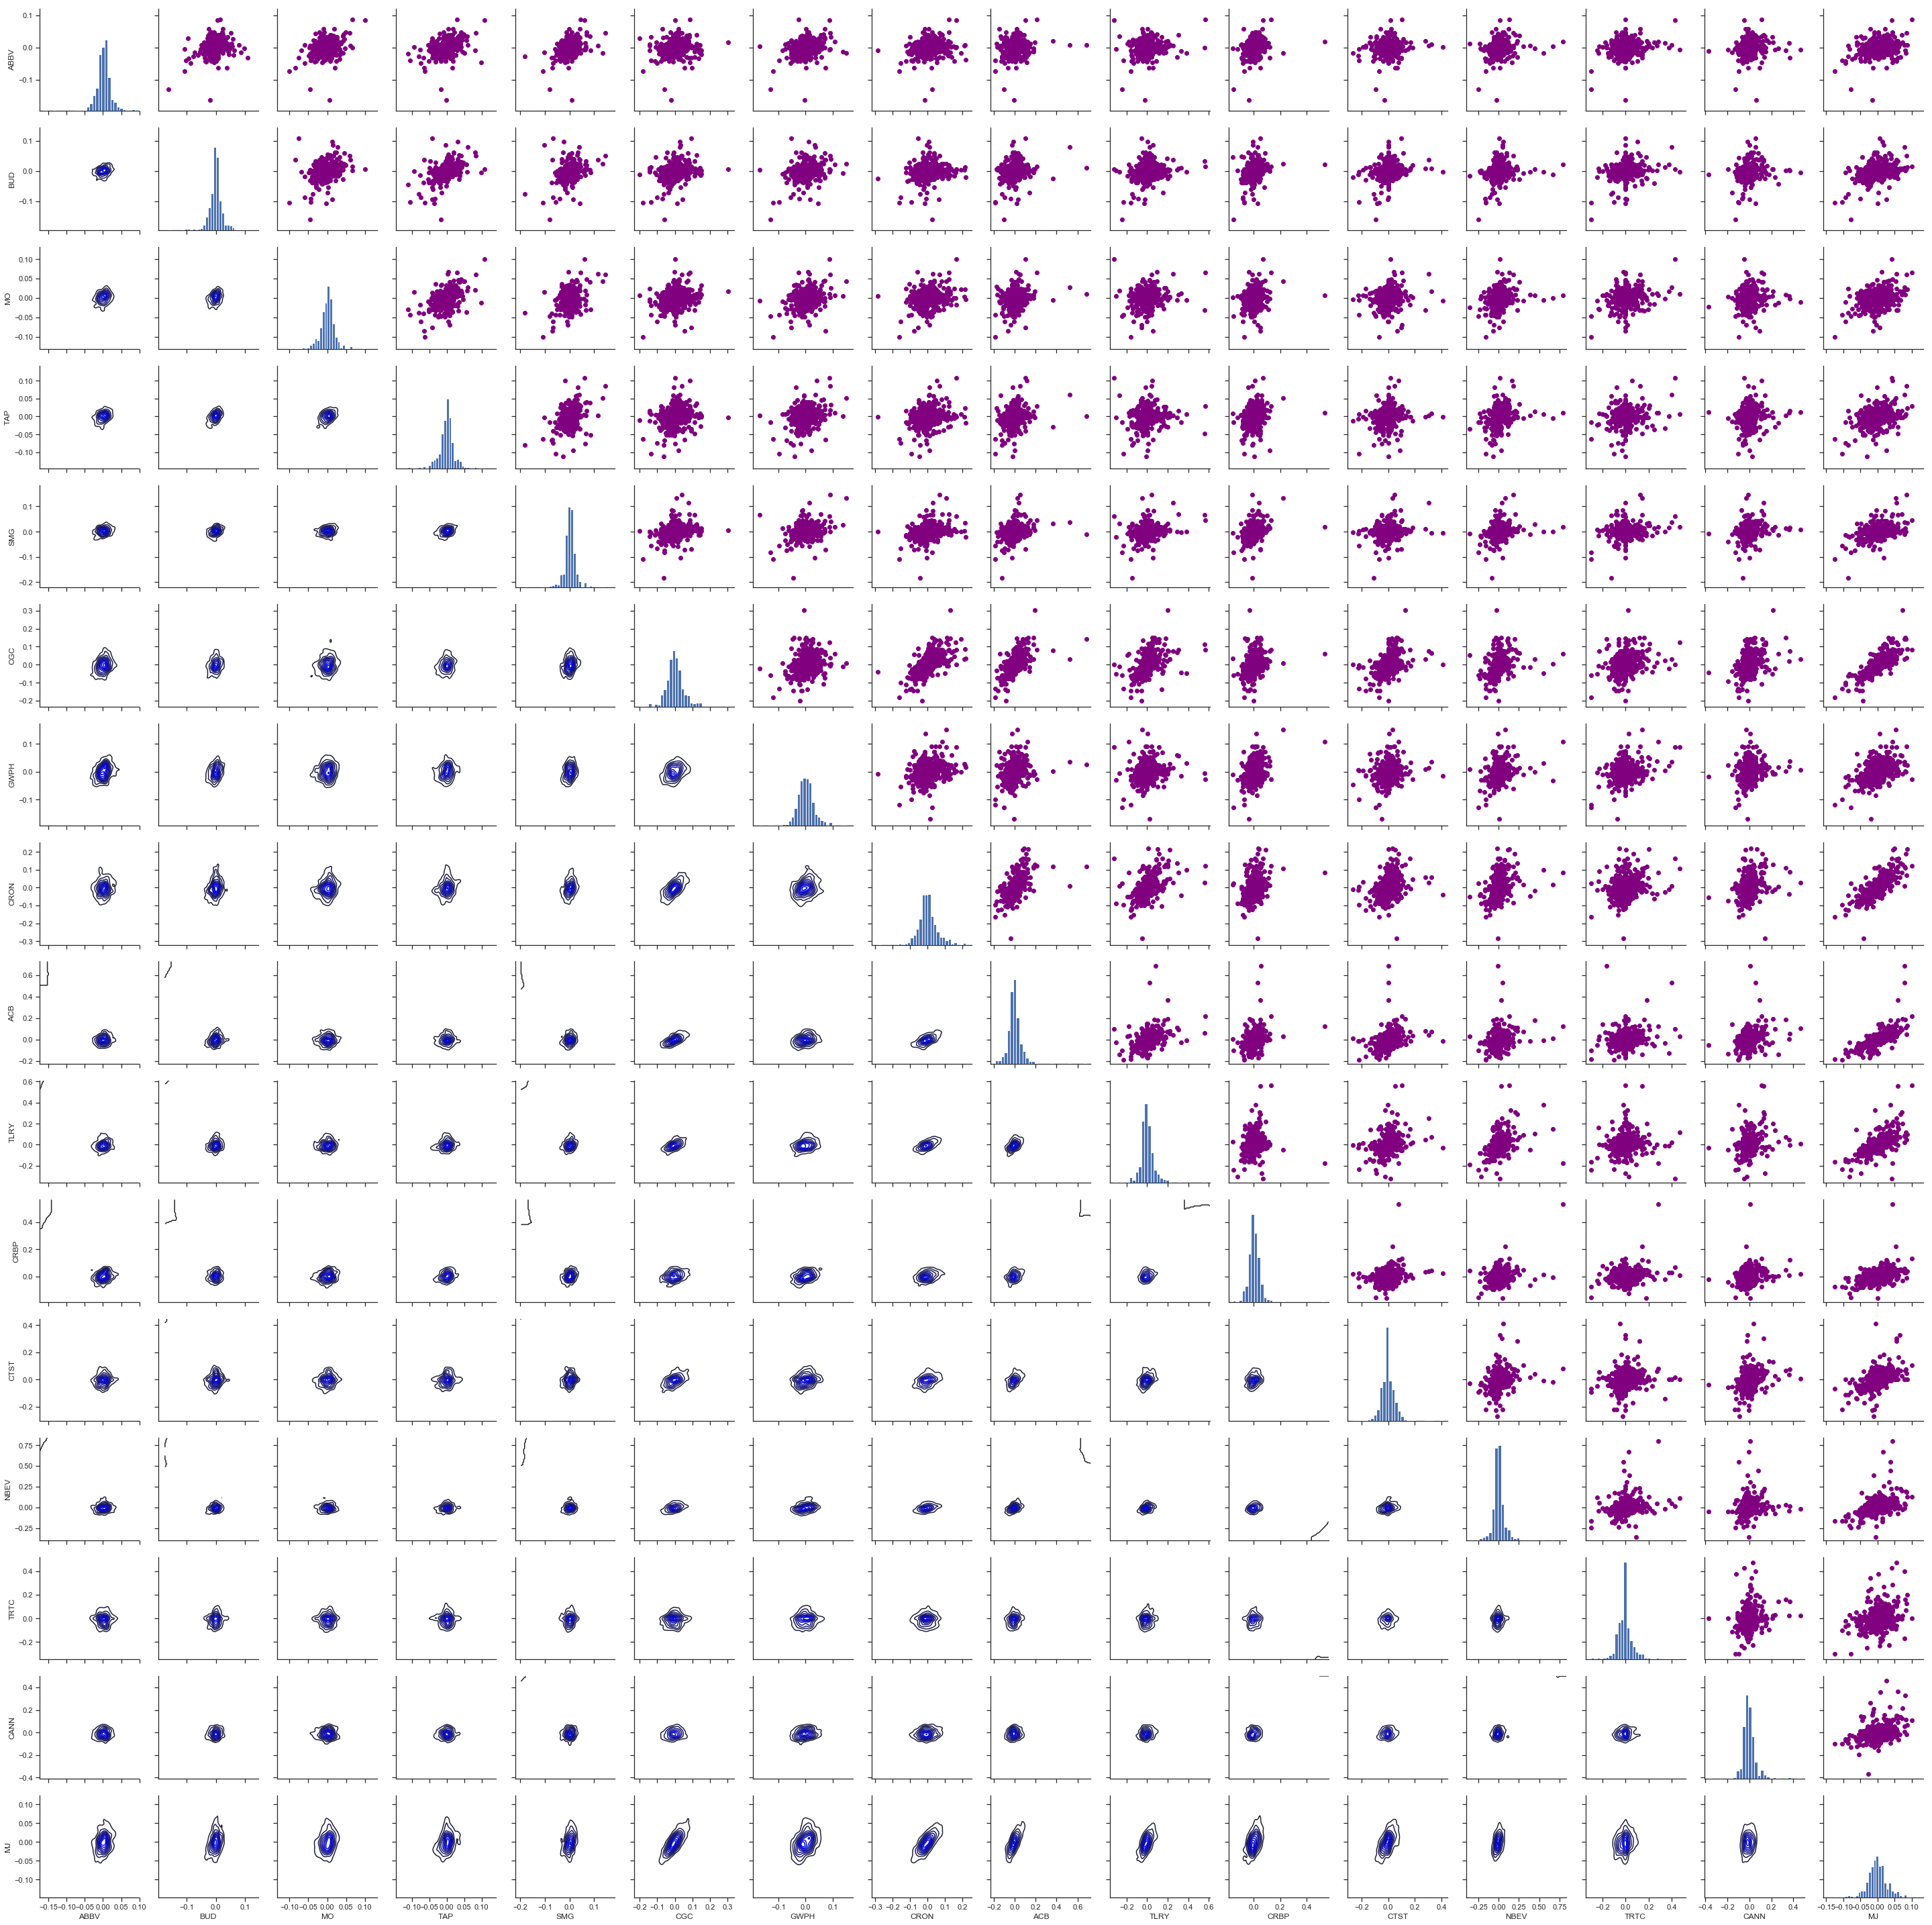

In [16]:
ax = sns.PairGrid(stock_rets)
ax.map_upper(plt.scatter, color='purple')
ax.map_lower(sns.kdeplot, color='blue')
ax.map_diag(plt.hist, bins=30)
for i in range(nplot) :
    for j in range(nplot) :
        ax.axes[i, j].locator_params(axis='x', nbins=6, tight=True)

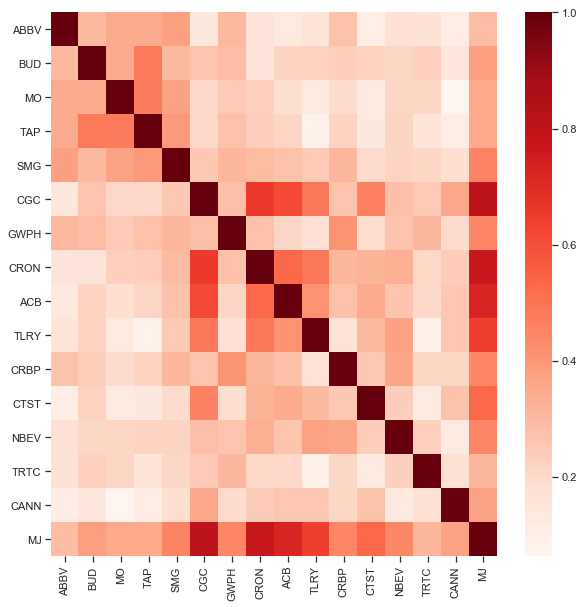

In [17]:
plt.figure(figsize=(10,10))
corr = stock_rets.corr()

# plot the heatmap
sns.heatmap(corr, 
        xticklabels=corr.columns,
        yticklabels=corr.columns,
            cmap="Reds")

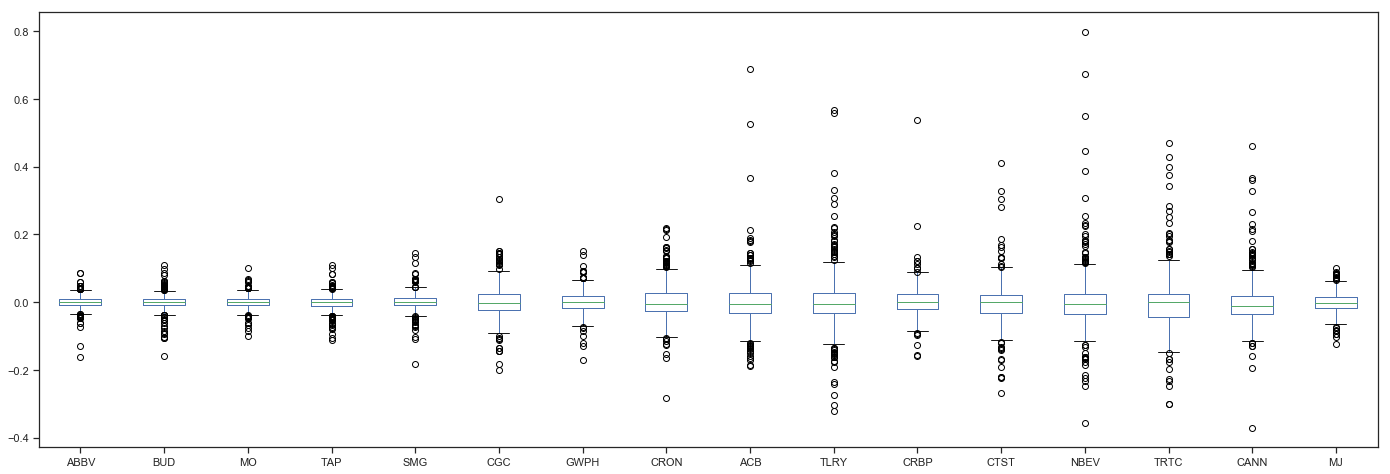

In [18]:
# Box plot
stock_rets.plot(kind='box',figsize=(24,8))

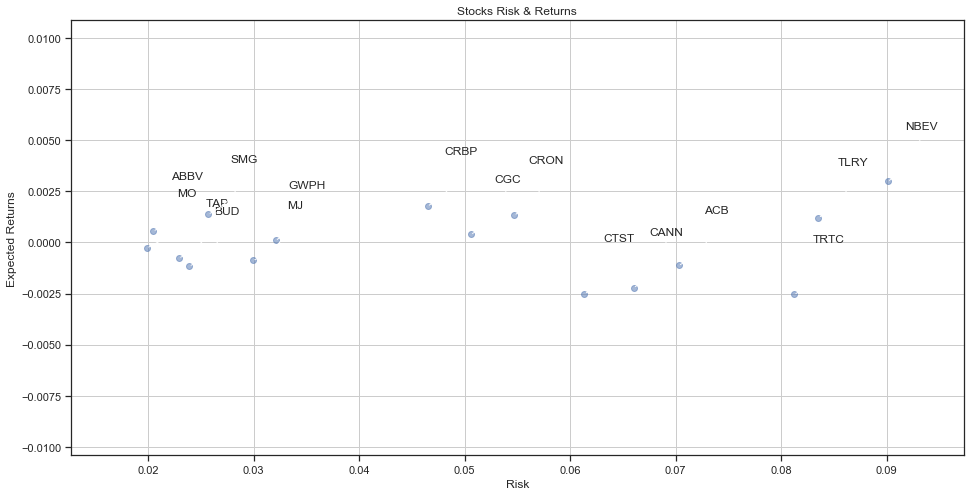

In [19]:
rets = stock_rets.dropna()

plt.figure(figsize=(16,8))
plt.scatter(rets.std(), rets.mean(),alpha = 0.5)

plt.title('Stocks Risk & Returns')
plt.xlabel('Risk')
plt.ylabel('Expected Returns')
plt.grid(which='major')

for label, x, y in zip(rets.columns, rets.std(), rets.mean()):
    plt.annotate(
        label, 
        xy = (x, y), xytext = (50, 50),
        textcoords = 'offset points', ha = 'right', va = 'bottom',
        arrowprops = dict(arrowstyle = '-', connectionstyle = 'arc3,rad=-0.3'))

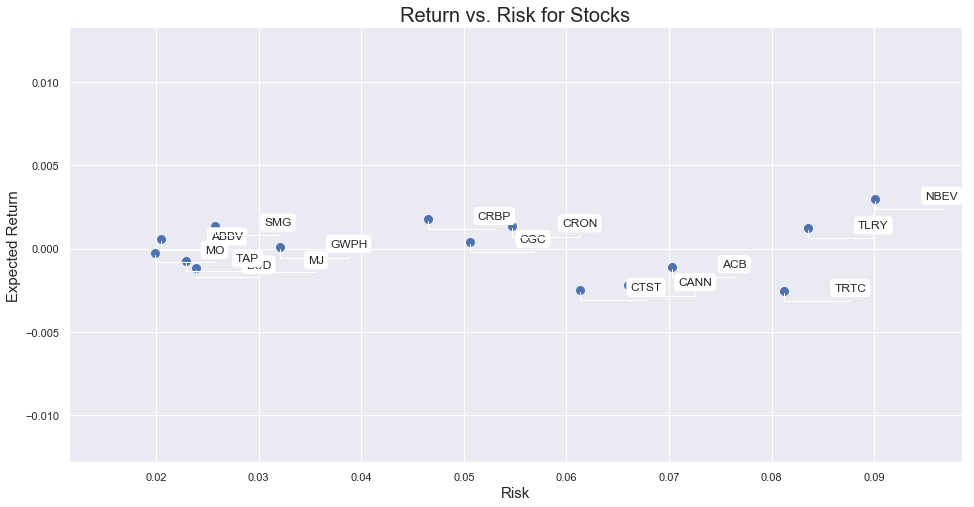

In [20]:
rets = stock_rets.dropna()
area = np.pi*20.0

sns.set(style='darkgrid')
plt.figure(figsize=(16,8))
plt.scatter(rets.std(), rets.mean(), s=area)
plt.xlabel("Risk", fontsize=15)
plt.ylabel("Expected Return", fontsize=15)
plt.title("Return vs. Risk for Stocks", fontsize=20)

for label, x, y in zip(rets.columns, rets.std(), rets.mean()) : 
    plt.annotate(label, xy=(x,y), xytext=(50, 0), textcoords='offset points',
                arrowprops=dict(arrowstyle='-', connectionstyle='bar,angle=180,fraction=-0.2'),
                bbox=dict(boxstyle="round", fc="w"))

In [21]:
rest_rets = rets.corr()
pair_value = rest_rets.abs().unstack()
pair_value.sort_values(ascending = False)

MJ    MJ      1.000000
CANN  CANN    1.000000
BUD   BUD     1.000000
MO    MO      1.000000
TAP   TAP     1.000000
SMG   SMG     1.000000
CGC   CGC     1.000000
GWPH  GWPH    1.000000
CRON  CRON    1.000000
ACB   ACB     1.000000
TLRY  TLRY    1.000000
CRBP  CRBP    1.000000
CTST  CTST    1.000000
NBEV  NBEV    1.000000
TRTC  TRTC    1.000000
ABBV  ABBV    1.000000
MJ    CGC     0.810819
CGC   MJ      0.810819
MJ    CRON    0.782384
CRON  MJ      0.782384
ACB   MJ      0.725535
MJ    ACB     0.725535
CRON  CGC     0.653592
CGC   CRON    0.653592
TLRY  MJ      0.640486
MJ    TLRY    0.640486
ACB   CGC     0.613705
CGC   ACB     0.613705
MJ    CTST    0.536440
CTST  MJ      0.536440
                ...   
CRON  ABBV    0.151795
ABBV  CRON    0.151795
BUD   CANN    0.148070
CANN  BUD     0.148070
CGC   ABBV    0.142989
ABBV  CGC     0.142989
CTST  TAP     0.140202
TAP   CTST    0.140202
ACB   ABBV    0.132702
ABBV  ACB     0.132702
MO    TLRY    0.130087
TLRY  MO      0.130087
CTST  TRTC 

In [22]:
# Normalized Returns Data
Normalized_Value = ((rets[:] - rets[:].min()) /(rets[:].max() - rets[:].min()))
Normalized_Value.head()

,ABBV,BUD,MO,TAP,SMG,CGC,GWPH,CRON,ACB,TLRY,CRBP,CTST,NBEV,TRTC,CANN,MJ
Date,,,,,,,,,,,,,,,,
2018-07-20,0.604578,0.635554,0.561502,0.435226,0.551081,0.310425,0.480990,0.482049,0.184212,0.732799,0.203233,0.363230,0.435448,0.411433,0.397675,0.524747
2018-07-23,0.672953,0.605948,0.495865,0.535980,0.549957,0.506239,0.482726,0.542339,0.256214,0.350436,0.202740,0.468312,0.316607,0.411062,0.395720,0.617023
2018-07-24,0.746747,0.599176,0.534830,0.591846,0.505120,0.362205,0.486289,0.508074,0.133584,0.206493,0.215911,0.391442,0.256177,0.446355,0.377724,0.470588
2018-07-25,0.720006,0.658794,0.488151,0.578326,0.570751,0.434735,0.522931,0.573099,0.194646,0.412568,0.215780,0.355515,0.329082,0.457614,0.491436,0.526045
2018-07-26,0.686147,0.409254,0.349327,0.500146,0.579742,0.355298,0.553044,0.519172,0.202836,0.358694,0.215646,0.317725,0.314885,0.493130,0.398628,0.461898


In [23]:
Normalized_Value.corr()

,ABBV,BUD,MO,TAP,SMG,CGC,GWPH,CRON,ACB,TLRY,CRBP,CTST,NBEV,TRTC,CANN,MJ
ABBV,1.000000,0.299752,0.345455,0.341370,0.376258,0.142989,0.303617,0.151795,0.132702,0.158178,0.276853,0.106502,0.175593,0.171783,0.111023,0.290858
BUD,0.299752,1.000000,0.341752,0.487035,0.300006,0.264805,0.290838,0.159286,0.224127,0.224583,0.238561,0.225768,0.212874,0.228349,0.148070,0.379891
MO,0.345455,0.341752,1.000000,0.480350,0.369055,0.203886,0.251809,0.233539,0.187347,0.130087,0.197093,0.124939,0.215947,0.216387,0.063279,0.350375
TAP,0.341370,0.487035,0.480350,1.000000,0.394010,0.204026,0.282370,0.235371,0.213307,0.081623,0.219056,0.140202,0.220178,0.155940,0.107233,0.349039
SMG,0.376258,0.300006,0.369055,0.394010,1.000000,0.254896,0.310430,0.294889,0.274614,0.253283,0.311451,0.194524,0.217895,0.210210,0.185494,0.458283
CGC,0.142989,0.264805,0.203886,0.204026,0.254896,1.000000,0.283343,0.653592,0.613705,0.489689,0.270534,0.459309,0.283808,0.251091,0.352733,0.810819
GWPH,0.303617,0.290838,0.251809,0.282370,0.310430,0.283343,1.000000,0.279702,0.211599,0.176141,0.413548,0.188948,0.271676,0.306750,0.195904,0.449297
CRON,0.151795,0.159286,0.233539,0.235371,0.294889,0.653592,0.279702,1.000000,0.535275,0.488517,0.312369,0.317387,0.332213,0.206619,0.245535,0.782384
ACB,0.132702,0.224127,0.187347,0.213307,0.274614,0.613705,0.211599,0.535275,1.000000,0.416411,0.282352,0.343071,0.264705,0.204751,0.258721,0.725535
TLRY,0.158178,0.224583,0.130087,0.081623,0.253283,0.489689,0.176141,0.488517,0.416411,1.000000,0.166846,0.298170,0.373232,0.093788,0.258778,0.640486


In [24]:
normalized_rets = Normalized_Value.corr()
normalized_pair_value = normalized_rets.abs().unstack()
normalized_pair_value.sort_values(ascending = False)

MJ    MJ      1.000000
CANN  CANN    1.000000
BUD   BUD     1.000000
MO    MO      1.000000
TAP   TAP     1.000000
SMG   SMG     1.000000
CGC   CGC     1.000000
GWPH  GWPH    1.000000
CRON  CRON    1.000000
ACB   ACB     1.000000
TLRY  TLRY    1.000000
CRBP  CRBP    1.000000
CTST  CTST    1.000000
NBEV  NBEV    1.000000
TRTC  TRTC    1.000000
ABBV  ABBV    1.000000
MJ    CGC     0.810819
CGC   MJ      0.810819
MJ    CRON    0.782384
CRON  MJ      0.782384
ACB   MJ      0.725535
MJ    ACB     0.725535
CRON  CGC     0.653592
CGC   CRON    0.653592
TLRY  MJ      0.640486
MJ    TLRY    0.640486
ACB   CGC     0.613705
CGC   ACB     0.613705
MJ    CTST    0.536440
CTST  MJ      0.536440
                ...   
CRON  ABBV    0.151795
ABBV  CRON    0.151795
BUD   CANN    0.148070
CANN  BUD     0.148070
CGC   ABBV    0.142989
ABBV  CGC     0.142989
CTST  TAP     0.140202
TAP   CTST    0.140202
ACB   ABBV    0.132702
ABBV  ACB     0.132702
MO    TLRY    0.130087
TLRY  MO      0.130087
CTST  TRTC 

In [25]:
print("Stock returns: ")
print(rets.mean())
print('-' * 50)
print("Stock risks:")
print(rets.std())

Stock returns: 
ABBV    0.000553
BUD    -0.001157
MO     -0.000263
TAP    -0.000762
SMG     0.001381
CGC     0.000400
GWPH    0.000103
CRON    0.001340
ACB    -0.001118
TLRY    0.001221
CRBP    0.001782
CTST   -0.002506
NBEV    0.002995
TRTC   -0.002544
CANN   -0.002204
MJ     -0.000878
dtype: float64
--------------------------------------------------
Stock risks:
ABBV    0.020498
BUD     0.023911
MO      0.019894
TAP     0.022924
SMG     0.025713
CGC     0.050582
GWPH    0.032086
CRON    0.054711
ACB     0.070286
TLRY    0.083543
CRBP    0.046494
CTST    0.061369
NBEV    0.090104
TRTC    0.081239
CANN    0.066023
MJ      0.029951
dtype: float64


In [26]:
table = pd.DataFrame()
table['Returns'] = rets.mean()
table['Risk'] = rets.std()
table.sort_values(by='Returns')

,Returns,Risk
TRTC,-0.002544,0.081239
CTST,-0.002506,0.061369
CANN,-0.002204,0.066023
BUD,-0.001157,0.023911
ACB,-0.001118,0.070286
MJ,-0.000878,0.029951
TAP,-0.000762,0.022924
MO,-0.000263,0.019894
GWPH,0.000103,0.032086
CGC,0.000400,0.050582


In [27]:
table.sort_values(by='Risk')

,Returns,Risk
MO,-0.000263,0.019894
ABBV,0.000553,0.020498
TAP,-0.000762,0.022924
BUD,-0.001157,0.023911
SMG,0.001381,0.025713
MJ,-0.000878,0.029951
GWPH,0.000103,0.032086
CRBP,0.001782,0.046494
CGC,0.000400,0.050582
CRON,0.001340,0.054711


In [28]:
rf = 0.01
table['Sharpe Ratio'] = (table['Returns'] - rf) / table['Risk']
table

,Returns,Risk,Sharpe Ratio
ABBV,0.000553,0.020498,-0.460876
BUD,-0.001157,0.023911,-0.466629
MO,-0.000263,0.019894,-0.515883
TAP,-0.000762,0.022924,-0.469473
SMG,0.001381,0.025713,-0.335198
CGC,0.000400,0.050582,-0.189792
GWPH,0.000103,0.032086,-0.308445
CRON,0.001340,0.054711,-0.158285
ACB,-0.001118,0.070286,-0.158187
TLRY,0.001221,0.083543,-0.105087


In [29]:
table['Max Returns'] = rets.max()

In [30]:
table['Min Returns'] = rets.min()

In [31]:
table['Median Returns'] = rets.median()

In [32]:
total_return = stock_rets[-1:].transpose()
table['Total Return'] = 100 * total_return
table

,Returns,Risk,Sharpe Ratio,Max Returns,Min Returns,Median Returns,Total Return
ABBV,0.000553,0.020498,-0.460876,0.087174,-0.162524,0.001478,-2.229985
BUD,-0.001157,0.023911,-0.466629,0.108361,-0.160081,-0.000360,-6.103648
MO,-0.000263,0.019894,-0.515883,0.100220,-0.100296,0.001163,-2.255825
TAP,-0.000762,0.022924,-0.469473,0.108333,-0.111761,0.000220,-3.871481
SMG,0.001381,0.025713,-0.335198,0.146244,-0.182526,0.001494,-1.781241
CGC,0.000400,0.050582,-0.189792,0.304224,-0.200276,-0.003133,-3.074250
GWPH,0.000103,0.032086,-0.308445,0.150662,-0.170612,-0.001091,-2.656000
CRON,0.001340,0.054711,-0.158285,0.217225,-0.284144,-0.004667,-2.297092
ACB,-0.001118,0.070286,-0.158187,0.686747,-0.188889,-0.006305,0.662740
TLRY,0.001221,0.083543,-0.105087,0.567460,-0.322689,-0.005014,-4.789729


In [33]:
table['Average Return Days'] = (1 + total_return)**(1 / days) - 1
table

,Returns,Risk,Sharpe Ratio,Max Returns,Min Returns,Median Returns,Total Return,Average Return Days
ABBV,0.000553,0.020498,-0.460876,0.087174,-0.162524,0.001478,-2.229985,-0.000025
BUD,-0.001157,0.023911,-0.466629,0.108361,-0.160081,-0.000360,-6.103648,-0.000070
MO,-0.000263,0.019894,-0.515883,0.100220,-0.100296,0.001163,-2.255825,-0.000025
TAP,-0.000762,0.022924,-0.469473,0.108333,-0.111761,0.000220,-3.871481,-0.000044
SMG,0.001381,0.025713,-0.335198,0.146244,-0.182526,0.001494,-1.781241,-0.000020
CGC,0.000400,0.050582,-0.189792,0.304224,-0.200276,-0.003133,-3.074250,-0.000035
GWPH,0.000103,0.032086,-0.308445,0.150662,-0.170612,-0.001091,-2.656000,-0.000030
CRON,0.001340,0.054711,-0.158285,0.217225,-0.284144,-0.004667,-2.297092,-0.000026
ACB,-0.001118,0.070286,-0.158187,0.686747,-0.188889,-0.006305,0.662740,0.000007
TLRY,0.001221,0.083543,-0.105087,0.567460,-0.322689,-0.005014,-4.789729,-0.000054


In [34]:
initial_value = df.iloc[0]
ending_value = df.iloc[-1]
table['CAGR'] = ((ending_value / initial_value) ** (252.0 / days)) -1
table

,Returns,Risk,Sharpe Ratio,Max Returns,Min Returns,Median Returns,Total Return,Average Return Days,CAGR
ABBV,0.000553,0.020498,-0.460876,0.087174,-0.162524,0.001478,-2.229985,-0.000025,0.028927
BUD,-0.001157,0.023911,-0.466629,0.108361,-0.160081,-0.000360,-6.103648,-0.000070,-0.191453
MO,-0.000263,0.019894,-0.515883,0.100220,-0.100296,0.001163,-2.255825,-0.000025,-0.110096
TAP,-0.000762,0.022924,-0.469473,0.108333,-0.111761,0.000220,-3.871481,-0.000044,-0.186360
SMG,0.001381,0.025713,-0.335198,0.146244,-0.182526,0.001494,-1.781241,-0.000020,0.068500
CGC,0.000400,0.050582,-0.189792,0.304224,-0.200276,-0.003133,-3.074250,-0.000035,-0.114805
GWPH,0.000103,0.032086,-0.308445,0.150662,-0.170612,-0.001091,-2.656000,-0.000030,-0.026709
CRON,0.001340,0.054711,-0.158285,0.217225,-0.284144,-0.004667,-2.297092,-0.000026,NaN
ACB,-0.001118,0.070286,-0.158187,0.686747,-0.188889,-0.006305,0.662740,0.000007,-0.446040
TLRY,0.001221,0.083543,-0.105087,0.567460,-0.322689,-0.005014,-4.789729,-0.000054,NaN


In [35]:
table.sort_values(by='Average Return Days')

,Returns,Risk,Sharpe Ratio,Max Returns,Min Returns,Median Returns,Total Return,Average Return Days,CAGR
NBEV,0.002995,0.090104,-0.077747,0.796339,-0.356098,-0.006292,-7.407408,-0.000085,-0.103526
BUD,-0.001157,0.023911,-0.466629,0.108361,-0.160081,-0.000360,-6.103648,-0.000070,-0.191453
TLRY,0.001221,0.083543,-0.105087,0.567460,-0.322689,-0.005014,-4.789729,-0.000054,NaN
CANN,-0.002204,0.066023,-0.184838,0.461404,-0.370235,-0.011137,-3.948599,-0.000045,-0.565101
TAP,-0.000762,0.022924,-0.469473,0.108333,-0.111761,0.000220,-3.871481,-0.000044,-0.186360
CGC,0.000400,0.050582,-0.189792,0.304224,-0.200276,-0.003133,-3.074250,-0.000035,-0.114805
MJ,-0.000878,0.029951,-0.363179,0.100909,-0.125220,-0.001668,-2.876109,-0.000032,-0.222094
GWPH,0.000103,0.032086,-0.308445,0.150662,-0.170612,-0.001091,-2.656000,-0.000030,-0.026709
CRBP,0.001782,0.046494,-0.176764,0.536232,-0.159806,0.000000,-2.331283,-0.000026,0.000350
CRON,0.001340,0.054711,-0.158285,0.217225,-0.284144,-0.004667,-2.297092,-0.000026,NaN
